In [7]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [8]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [9]:
# Delhi hourly AQI dataset
delhi_df = pd.read_csv('Delhi_AQI_Dataset.csv')

# India daily AQI dataset
india_df = pd.read_csv('Dataset_AQI30-4.csv')

# Quick check
print(delhi_df.head())
print(india_df.head())

    City      Date  AQI  PM2.5    PM10     NO2     SO2    CO     O3  \
0  Delhi  01/01/18  406  223.3  438.48  336.98  462.84  4.26  385.7   
1  Delhi  02/01/18  418  229.9  451.44  346.94  476.52  4.39  397.1   
2  Delhi  03/01/18  382  210.1  412.56  317.06  435.48  4.01  362.9   
3  Delhi  04/01/18  366  201.3  395.28  303.78  417.24  3.84  347.7   
4  Delhi  05/01/18  390  214.5  421.20  323.70  444.60  4.10  370.5   

   Unnamed: 9  Unnamed: 10  
0         NaN          NaN  
1         NaN          NaN  
2         NaN          NaN  
3         NaN          NaN  
4         NaN          NaN  
                                            City AQI  PM2.5  PM10    O3   NO2  \
0                    Gulzarpet, Anantapur, India  76   76.0  52.0  19.0   5.1   
1  Anand Kala Kshetram, Rajamahendravaram, India  23    9.0  23.0   5.3   2.1   
2                Tirumala-APPCB, Tirupati, India  70   70.0  50.0  16.8  10.6   
3                 PWD Grounds, Vijayawada, India   -   52.0   NaN   5.1   0

In [10]:
# Check shape
print("Delhi dataset shape:", delhi_df.shape)
print("India dataset shape:", india_df.shape)

# Check columns
print(delhi_df.columns)
print(india_df.columns)

# Check for missing values
print(delhi_df.isnull().sum())
print(india_df.isnull().sum())

# Quick statistics
print(delhi_df.describe())
print(india_df.describe())

Delhi dataset shape: (2191, 11)
India dataset shape: (153, 11)
Index(['City', 'Date', 'AQI', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3',
       'Unnamed: 9', 'Unnamed: 10'],
      dtype='object')
Index(['City', 'AQI', 'PM2.5', 'PM10', 'O3', 'NO2', 'SO2', 'CO', 'Latitude',
       'Longitude', 'Time'],
      dtype='object')
City              0
Date              0
AQI               0
PM2.5             0
PM10              0
NO2               0
SO2               0
CO                0
O3                0
Unnamed: 9     2191
Unnamed: 10    2191
dtype: int64
City          0
AQI           0
PM2.5         7
PM10         17
O3           19
NO2          14
SO2          17
CO           20
Latitude      0
Longitude     0
Time          1
dtype: int64
               AQI        PM2.5         PM10          NO2          SO2  \
count  2191.000000  2191.000000  2191.000000  2191.000000  2191.000000   
mean    208.285714   114.557143   224.948571   172.877143   237.445714   
std     106.614654    58.638060  

In [11]:
# For Delhi dataset
# Drop rows with missing AQI
delhi_df = delhi_df.dropna(subset=['AQI'])

# Fill missing pollutant values with median
pollutants = ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3', 'Temperature', 'Humidity']
for col in pollutants:
    if col in delhi_df.columns:
        delhi_df[col].fillna(delhi_df[col].median(), inplace=True)

# Convert Date column to datetime (if exists)
if 'Date' in delhi_df.columns:
    delhi_df['Date'] = pd.to_datetime(delhi_df['Date'])
    delhi_df['Day'] = delhi_df['Date'].dt.day
    delhi_df['Month'] = delhi_df['Date'].dt.month
    delhi_df['Hour'] = delhi_df['Date'].dt.hour

/tmp/ipykernel_1076/215140690.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  delhi_df[col].fillna(delhi_df[col].median(), inplace=True)
/tmp/ipykernel_1076/215140690.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  delhi_df['Date'] = pd.to_datetime(delhi_df['Date'])


In [12]:
# For India dataset
india_df['AQI'] = pd.to_numeric(india_df['AQI'], errors='coerce')
india_df = india_df.dropna(subset=['AQI'])

# Fill missing pollutant values
for col in pollutants:
    if col in india_df.columns:
        india_df[col].fillna(india_df[col].median(), inplace=True)

# Convert Time column to datetime and extract Day and Month
if 'Time' in india_df.columns:
    india_df['Time'] = pd.to_datetime(india_df['Time'])
    india_df['Day'] = india_df['Time'].dt.day
    india_df['Month'] = india_df['Time'].dt.month

/tmp/ipykernel_1076/70012856.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  india_df[col].fillna(india_df[col].median(), inplace=True)


In [13]:
# Features and target for Delhi dataset
X_delhi = delhi_df[['PM2.5','PM10','NO2','SO2','CO','O3','Day','Month','Hour']]
y_delhi = delhi_df['AQI']

# Split Delhi data
X_train_delhi, X_test_delhi, y_train_delhi, y_test_delhi = train_test_split(X_delhi, y_delhi, test_size=0.2, random_state=42)

# Features and target for India dataset
X_india = india_df[['PM2.5','PM10','NO2','SO2','CO','O3','Day','Month']]
y_india = india_df['AQI']

# Split India data
X_train_india, X_test_india, y_train_india, y_test_india = train_test_split(X_india, y_india, test_size=0.2, random_state=42)

In [14]:
# Delhi dataset
X_train_delhi, X_test_delhi, y_train_delhi, y_test_delhi = train_test_split(
    X_delhi, y_delhi, test_size=0.2, random_state=42
)

# India dataset
X_train_india, X_test_india, y_train_india, y_test_india = train_test_split(
    X_india, y_india, test_size=0.2, random_state=42
)

In [15]:
scaler_delhi = StandardScaler()
X_train_delhi_scaled = scaler_delhi.fit_transform(X_train_delhi)
X_test_delhi_scaled = scaler_delhi.transform(X_test_delhi)

scaler_india = StandardScaler()
X_train_india_scaled = scaler_india.fit_transform(X_train_india)
X_test_india_scaled = scaler_india.transform(X_test_india)

In [16]:
# Delhi AQI Model
rf_delhi = RandomForestRegressor(n_estimators=100, random_state=42)
rf_delhi.fit(X_train_delhi_scaled, y_train_delhi)

# India AQI Model
rf_india = RandomForestRegressor(n_estimators=100, random_state=42)
rf_india.fit(X_train_india_scaled, y_train_india)

RandomForestRegressor(random_state=42)

In [17]:
# Delhi dataset
y_pred_delhi = rf_delhi.predict(X_test_delhi_scaled)
print("Delhi Dataset Evaluation:")
print("MAE:", mean_absolute_error(y_test_delhi, y_pred_delhi))
print("MSE:", mean_squared_error(y_test_delhi, y_pred_delhi))
print("RMSE:", np.sqrt(mean_squared_error(y_test_delhi, y_pred_delhi)))
print("R2 Score:", r2_score(y_test_delhi, y_pred_delhi))

# India dataset
y_pred_india = rf_india.predict(X_test_india_scaled)
print("\nIndia Dataset Evaluation:")
print("MAE:", mean_absolute_error(y_test_india, y_pred_india))
print("MSE:", mean_squared_error(y_test_india, y_pred_india))
print("RMSE:", np.sqrt(mean_squared_error(y_test_india, y_pred_india)))
print("R2 Score:", r2_score(y_test_india, y_pred_india))

Delhi Dataset Evaluation:
MAE: 0.06421412300683285
MSE: 0.02077562642369019
RMSE: 0.1441375260773203
R2 Score: 0.9999981127502148

India Dataset Evaluation:
MAE: 6.691666666666669
MSE: 141.30564999999999
RMSE: 11.887205306547035
R2 Score: 0.9427804241017196


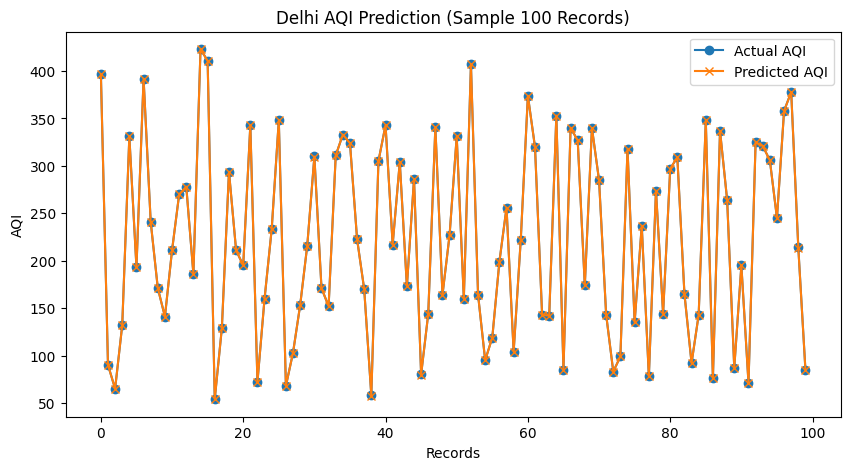

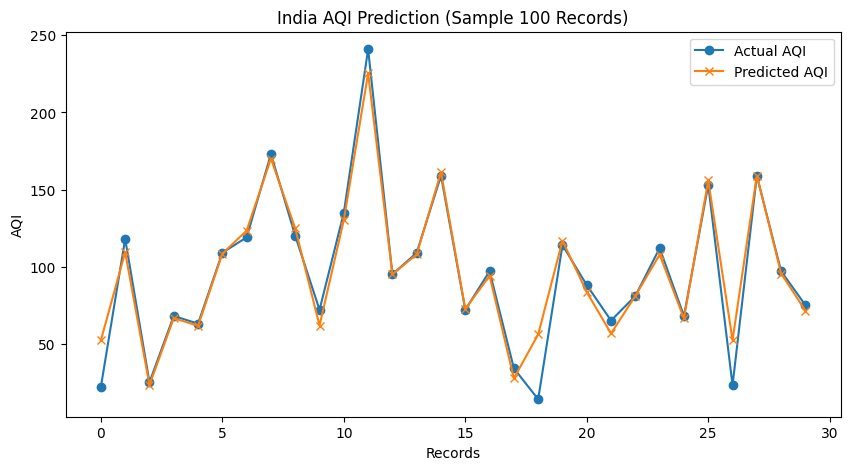

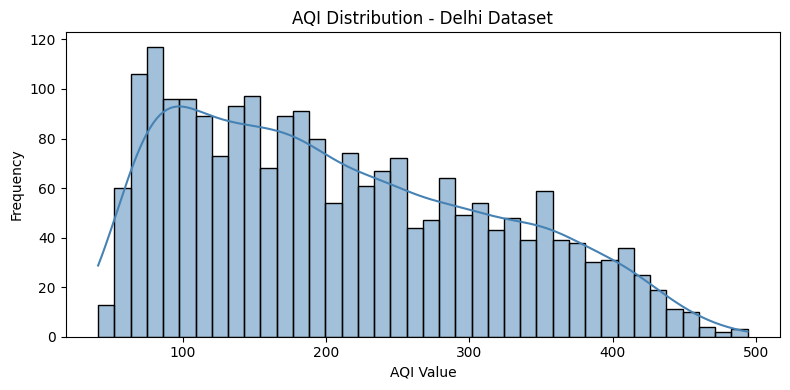

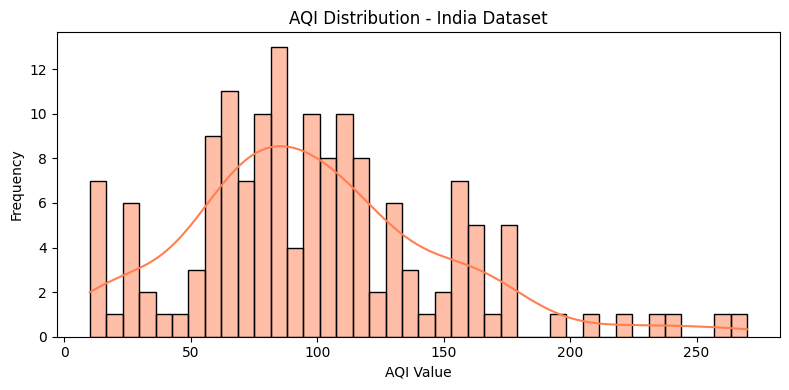

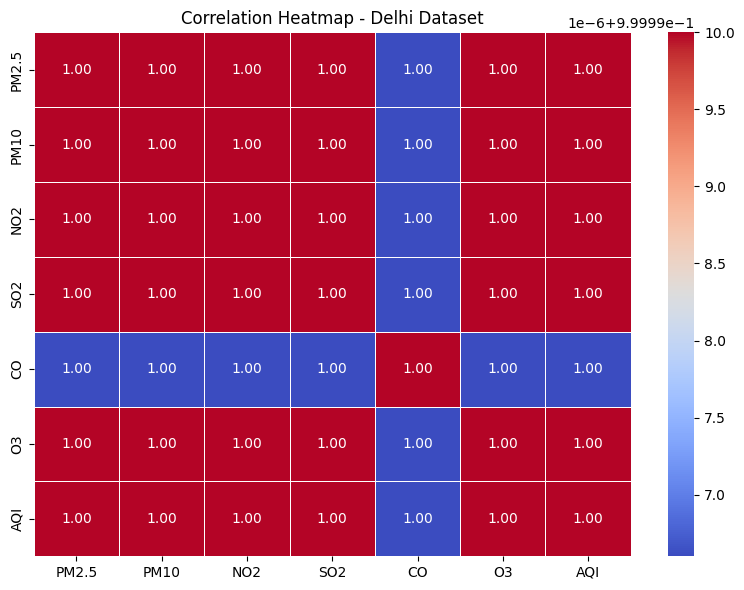

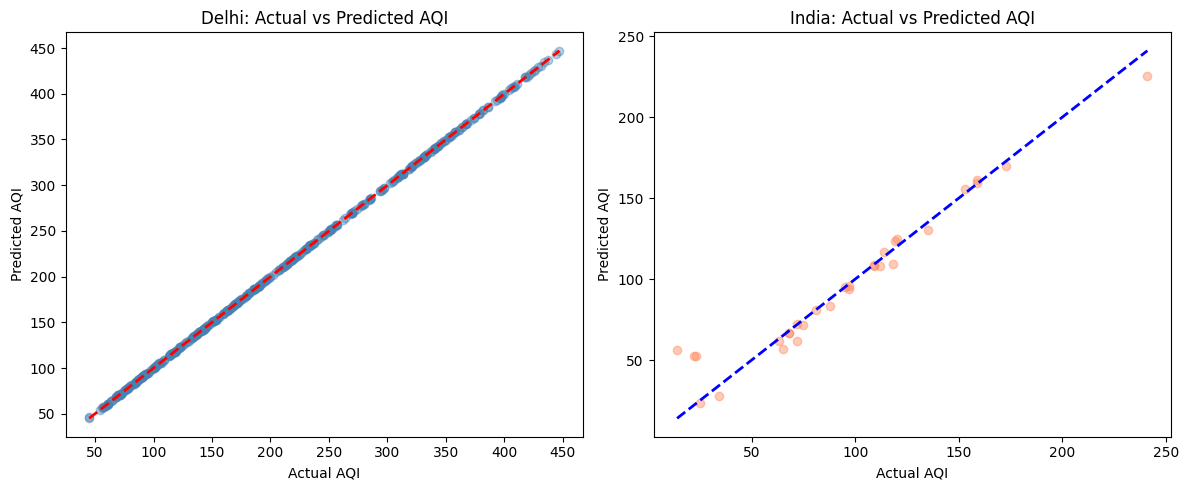

In [18]:
# Delhi AQI
plt.figure(figsize=(10,5))
plt.plot(y_test_delhi.values[:100], label='Actual AQI', marker='o')
plt.plot(y_pred_delhi[:100], label='Predicted AQI', marker='x')
plt.title('Delhi AQI Prediction (Sample 100 Records)')
plt.xlabel('Records')
plt.ylabel('AQI')
plt.legend()
plt.show()

# India AQI
plt.figure(figsize=(10,5))
plt.plot(y_test_india.values[:100], label='Actual AQI', marker='o')
plt.plot(y_pred_india[:100], label='Predicted AQI', marker='x')
plt.title('India AQI Prediction (Sample 100 Records)')
plt.xlabel('Records')
plt.ylabel('AQI')
plt.legend()
plt.show()

# AQI Distribution for Delhi
plt.figure(figsize=(8, 4))
sns.histplot(delhi_df['AQI'].dropna(), bins=40, kde=True, color='steelblue')
plt.title('AQI Distribution - Delhi Dataset')
plt.xlabel('AQI Value')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# AQI Distribution for India
plt.figure(figsize=(8, 4))
sns.histplot(india_df['AQI'].dropna(), bins=40, kde=True, color='coral')
plt.title('AQI Distribution - India Dataset')
plt.xlabel('AQI Value')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Correlation Heatmap for Delhi
delhi_pollutants = ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3', 'AQI']
delhi_corr_cols = [col for col in delhi_pollutants if col in delhi_df.columns]

plt.figure(figsize=(8, 6))
sns.heatmap(
    delhi_df[delhi_corr_cols].corr(),
    annot=True, fmt='.2f',
    cmap='coolwarm', linewidths=0.5
)
plt.title('Correlation Heatmap - Delhi Dataset')
plt.tight_layout()
plt.show()

# Scatter Plot: Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test_delhi, y_pred_delhi, alpha=0.4, color='steelblue')
axes[0].plot([y_test_delhi.min(), y_test_delhi.max()],
             [y_test_delhi.min(), y_test_delhi.max()], 'r--', linewidth=2)
axes[0].set_title('Delhi: Actual vs Predicted AQI')
axes[0].set_xlabel('Actual AQI')
axes[0].set_ylabel('Predicted AQI')

axes[1].scatter(y_test_india, y_pred_india, alpha=0.4, color='coral')
axes[1].plot([y_test_india.min(), y_test_india.max()],
             [y_test_india.min(), y_test_india.max()], 'b--', linewidth=2)
axes[1].set_title('India: Actual vs Predicted AQI')
axes[1].set_xlabel('Actual AQI')
axes[1].set_ylabel('Predicted AQI')

plt.tight_layout()
plt.show()

In [19]:
!pip install ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 48.4 MB/s eta 0:00:00


In [20]:
import ipywidgets as widgets
from IPython.display import display

In [21]:
# Define sliders
pm25 = widgets.FloatSlider(min=0, max=500, step=1, description='PM2.5')
pm10 = widgets.FloatSlider(min=0, max=500, step=1, description='PM10')
no2 = widgets.FloatSlider(min=0, max=200, step=1, description='NO2')
so2 = widgets.FloatSlider(min=0, max=100, step=1, description='SO2')
co = widgets.FloatSlider(min=0, max=50, step=0.1, description='CO')
o3 = widgets.FloatSlider(min=0, max=200, step=1, description='O3')
day = widgets.IntSlider(min=1, max=31, step=1, description='Day')
month = widgets.IntSlider(min=1, max=12, step=1, description='Month')
hour = widgets.IntSlider(min=0, max=23, step=1, description='Hour')

In [22]:
def predict_aqi_delhi(pm25_val, pm10_val, no2_val, so2_val, co_val, o3_val, day_val, month_val, hour_val):
    # Create dataframe from input
    input_data = pd.DataFrame([[pm25_val, pm10_val, no2_val, so2_val, co_val, o3_val, day_val, month_val, hour_val]],
                              columns=['PM2.5','PM10','NO2','SO2','CO','O3','Day','Month','Hour'])

    # Scale input
    input_scaled = scaler_delhi.transform(input_data)

    # Predict AQI
    predicted_aqi = rf_delhi.predict(input_scaled)[0]

    print(f"Predicted AQI for Delhi: {predicted_aqi:.2f}")

In [23]:
interactive_pred = widgets.interactive(
    predict_aqi_delhi,
    pm25_val=pm25,
    pm10_val=pm10,
    no2_val=no2,
    so2_val=so2,
    co_val=co,
    o3_val=o3,
    day_val=day,
    month_val=month,
    hour_val=hour
)

display(interactive_pred)

interactive(children=(FloatSlider(value=0.0, description='PM2.5', max=500.0, step=1.0), FloatSlider(value=0.0,…

In [24]:
def predict_aqi_india(pm25_val, pm10_val, no2_val, so2_val, co_val, o3_val, day_val, month_val):
    input_data = pd.DataFrame([[pm25_val, pm10_val, no2_val, so2_val, co_val, o3_val, day_val, month_val]],
                              columns=['PM2.5','PM10','NO2','SO2','CO','O3','Day','Month'])
    input_scaled = scaler_india.transform(input_data)
    predicted_aqi = rf_india.predict(input_scaled)[0]
    print(f"Predicted AQI (India dataset): {predicted_aqi:.2f}")

# Create sliders (no Hour, Temperature, or Humidity)
interactive_pred_india = widgets.interactive(
    predict_aqi_india,
    pm25_val=pm25,
    pm10_val=pm10,
    no2_val=no2,
    so2_val=so2,
    co_val=co,
    o3_val=o3,
    day_val=day,
    month_val=month
)

display(interactive_pred_india)

interactive(children=(FloatSlider(value=0.0, description='PM2.5', max=500.0, step=1.0), FloatSlider(value=0.0,…